# Task 10: WGAN-GP for Stable Image Synthesis



In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset size:", len(dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.85MB/s]

Dataset size: 60000


## 2. Generator

In [3]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


G = Generator().to(device)

## 3. Critic

In [4]:
class Critic(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)


D = Critic().to(device)

## 4. Gradient Penalty



In [5]:
def gradient_penalty(real, fake):

    alpha = torch.rand(
        real.size(0), 1, 1, 1,
        device=device
    )

    # Interpolate between real and fake images.
    mixed = alpha * real + (1 - alpha) * fake
    mixed.requires_grad_(True)

    score = D(mixed)

    gradients = torch.autograd.grad(
        outputs=score,
        inputs=mixed,
        grad_outputs=torch.ones_like(score),
        create_graph=True
    )[0]

    gradients = gradients.view(
        gradients.size(0), -1
    )

    norm = gradients.norm(2, dim=1)

    penalty = ((norm - 1) ** 2).mean()

    return penalty

## 5. Train WGAN-GP

In [9]:
opt_G = torch.optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.9)
)

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.9)
)

lambda_gp = 10
epochs = 50

g_losses = []
d_losses = []

for epoch in range(epochs):

    for real, _ in loader:

        real = real.to(device)
        batch = real.size(0)

        # -------------------------
        # Train Critic
        # -------------------------

        z = torch.randn(
            batch, 100,
            device=device
        )

        fake = G(z).detach()

        real_score = D(real).mean()
        fake_score = D(fake).mean()

        gp = gradient_penalty(
            real, fake
        )

        d_loss = (
            fake_score
            - real_score
            + lambda_gp * gp
        )

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        z = torch.randn(
            batch, 100,
            device=device
        )

        fake = G(z)

        g_loss = -D(fake).mean()

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    print(
        f"Epoch {epoch + 1:3d}/100 | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch   1/100 | D Loss: -4.1216 | G Loss: 3.4737
Epoch   2/100 | D Loss: -3.7709 | G Loss: 2.5466
Epoch   3/100 | D Loss: -3.4082 | G Loss: 2.0466
Epoch   4/100 | D Loss: -3.1810 | G Loss: 3.1598
Epoch   5/100 | D Loss: -2.1330 | G Loss: 1.8709
Epoch   6/100 | D Loss: -2.2191 | G Loss: 0.1163
Epoch   7/100 | D Loss: -2.3199 | G Loss: -1.8665
Epoch   8/100 | D Loss: -1.7261 | G Loss: -0.2918
Epoch   9/100 | D Loss: -2.2041 | G Loss: -2.5519
Epoch  10/100 | D Loss: -1.5515 | G Loss: -2.0733
Epoch  11/100 | D Loss: -1.2798 | G Loss: -2.5844
Epoch  12/100 | D Loss: -1.3951 | G Loss: -3.0077
Epoch  13/100 | D Loss: -0.9845 | G Loss: -1.2977
Epoch  14/100 | D Loss: -1.3331 | G Loss: -2.9153
Epoch  15/100 | D Loss: -1.1514 | G Loss: -2.0468
Epoch  16/100 | D Loss: -1.4020 | G Loss: -1.0650
Epoch  17/100 | D Loss: -0.8336 | G Loss: -3.5913
Epoch  18/100 | D Loss: -1.2707 | G Loss: -4.1193
Epoch  19/100 | D Loss: -1.0995 | G Loss: -1.7540
Epoch  20/100 | D Loss: -1.0353 | G Loss: 0.2021
Epoch  

## 6. Plot Training Losses

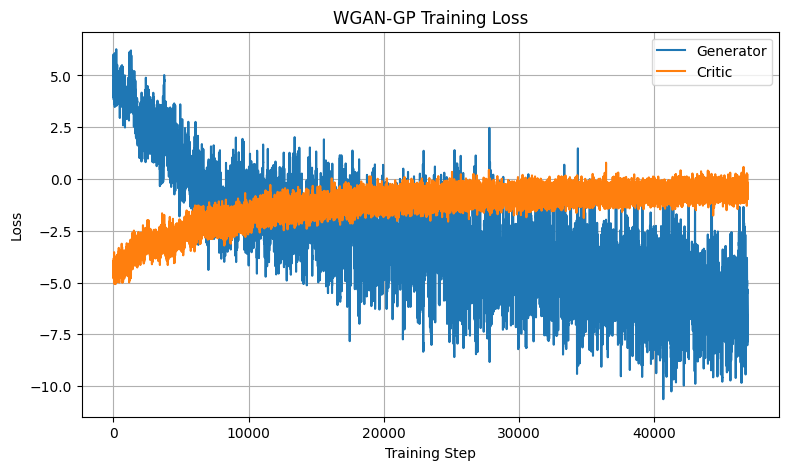

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Critic")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("WGAN-GP Training Loss")
plt.legend()
plt.grid()
plt.show()

## 7. Generate Images

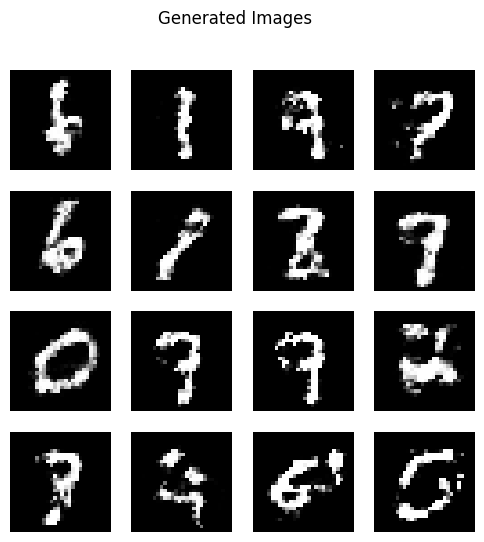

In [11]:
G.eval()

z = torch.randn(
    16, 100,
    device=device
)

with torch.no_grad():
    images = G(z).cpu()

plt.figure(figsize=(6, 6))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        images[i, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Generated Images")
plt.show()